In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Dosyaları okuyoruz
customers = pd.read_csv('/content/olist_customers_dataset.csv')
orders = pd.read_csv('/content/olist_orders_dataset.csv')
payments = pd.read_csv('/content/olist_order_payments_dataset.csv')

print("Dosyalar başarıyla okundu.")

Dosyalar başarıyla okundu.


In [ ]:
# 1. Tabloları birleştir (Customer_unique_id bizim için gerçek kişiyi temsil eder)
df = pd.merge(orders, customers, on='customer_id')
df = pd.merge(df, payments, on='order_id')

In [ ]:
# 2. Sadece ihtiyacımız olan sütunları seçelim
df = df[['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'payment_value', 'order_status']]

# 3. Temizlik: Sadece teslim edilmiş (delivered) siparişleri alalım (İptaller analizi bozmasın)
df = df[df['order_status'] == 'delivered']

# 4. Tarih sütununu düzeltme
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Eksik veri kontrolü
print("Eksik veri sayısı:\n", df.isnull().sum())
print("\nVeri setinin son hali:")
df.head()

Eksik veri sayısı:
 customer_unique_id          0
order_id                    0
order_purchase_timestamp    0
payment_value               0
order_status                0
dtype: int64

Veri setinin son hali:


,customer_unique_id,order_id,order_purchase_timestamp,payment_value,order_status
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,18.12,delivered
1,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2.00,delivered
2,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,18.59,delivered
3,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46,delivered
4,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12,delivered


In [ ]:
# Analiz tarihi (Verideki son tarihten 1 gün sonrası)
today_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# RFM Tablosu oluşturma
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (today_date - x.max()).days, # Recency
    'order_id': 'nunique',                                            # Frequency
    'payment_value': 'sum'                                            # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Sıklığı 0 olan veya hatalı verileri filtreleyelim
rfm = rfm[rfm['Monetary'] > 0]

print("RFM Tablosu oluşturuldu. Örnek:")
rfm.head()

RFM Tablosu oluşturuldu. Örnek:


,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [ ]:
# Verideki çarpıklığı (skewness) gidermek için log dönüşümü (opsiyonel ama önerilir)
rfm_log = rfm.copy()
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

# Ölçeklendirme (StandardScaler)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)
print("Veri modele hazır hale getirildi.")

Veri modele hazır hale getirildi.


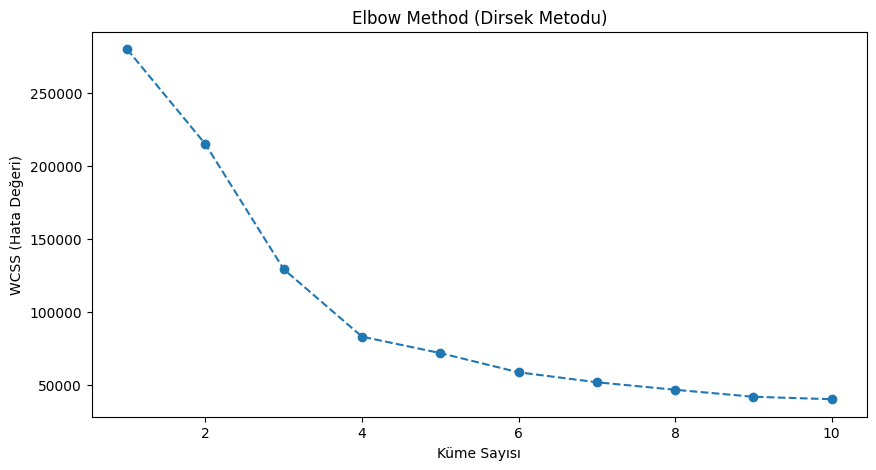

In [ ]:
# Optimal küme sayısını bulma
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method (Dirsek Metodu)')
plt.xlabel('Küme Sayısı')
plt.ylabel('WCSS (Hata Değeri)')
plt.show()

In [ ]:
# Modeli eğitme
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Müşteriler 4 gruba ayrıldı.")

Müşteriler 4 gruba ayrıldı.


Küme Bazlı Müşteri Profilleri:
        Recency        Frequency Monetary
           mean  count      mean     mean
Cluster                                  
0         287.9  42337       1.0     68.4
1         271.8  32111       1.0    296.5
2         220.3   2801       2.1    308.6
3          42.1  16108       1.0    133.0


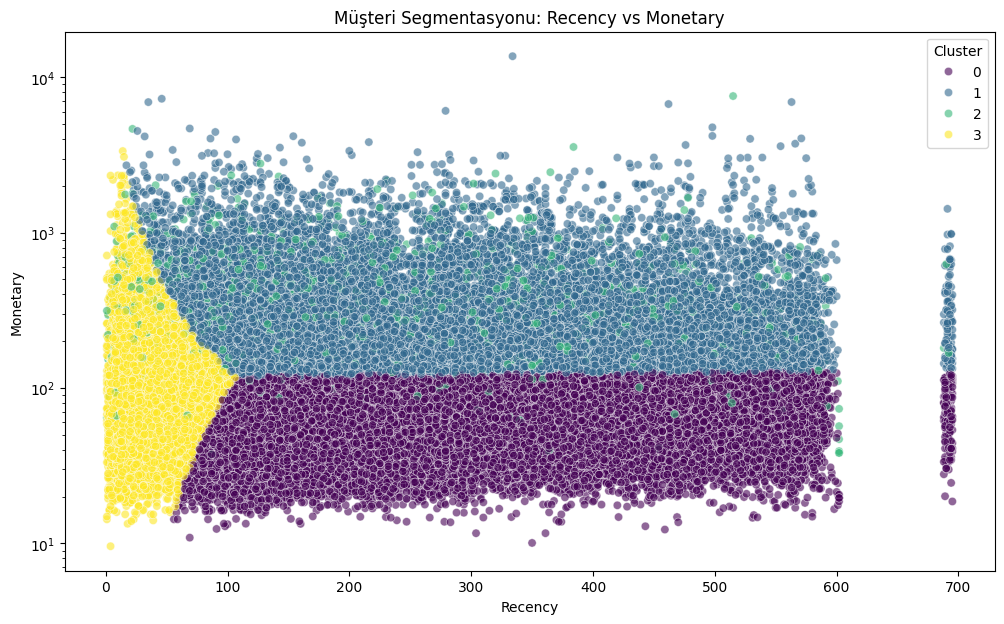

In [ ]:
# Grupların ortalamalarını inceleyelim
analysis = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'count'],
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

print("Küme Bazlı Müşteri Profilleri:")
print(analysis)

# Görselleştirme: Recency vs Monetary
plt.figure(figsize=(12,7))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis', alpha=0.6)
plt.title('Müşteri Segmentasyonu: Recency vs Monetary')
plt.yscale('log') # Para değerleri çok değişken olduğu için logaritmik eksen
plt.show()

1. Adım: Veri birleştirme ve temizleme tamamlandı.
2. Adım: RFM tablosu oluşturuldu.
3. Adım: Veri ölçeklendirme (Scaling) tamamlandı.


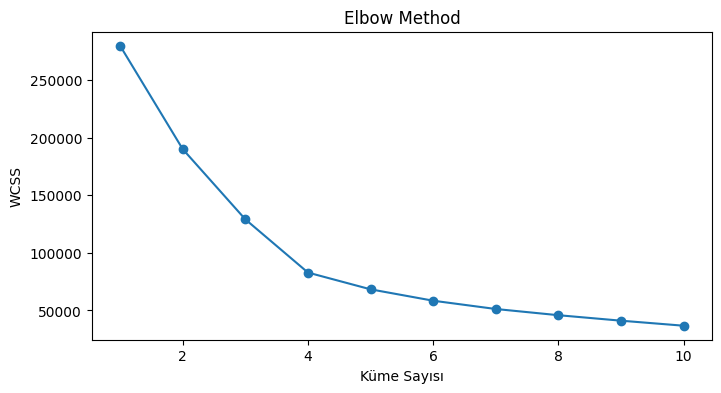

4. Adım: K-Means modeli 4 küme ile eğitildi.

Küme Bazlı Müşteri Profilleri:
        Recency        Frequency Monetary
           mean  count      mean     mean
Cluster                                  
0         272.5  32185       1.0    295.8
1         287.3  42287       1.0     68.2
2         220.3   2801       2.1    308.6
3          42.0  16084       1.0    133.9


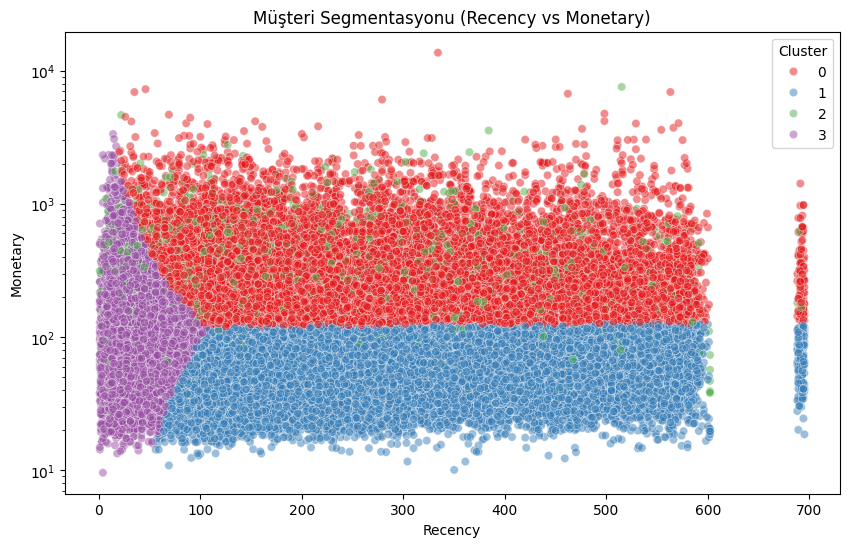

In [ ]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

class RFMClustering:
    def __init__(self, customers_path, orders_path, payments_path):
        """Dosya yollarını alır ve temel verileri yükler."""
        self.customers = pd.read_csv(customers_path)
        self.orders = pd.read_csv(orders_path)
        self.payments = pd.read_csv(payments_path)
        self.df = None
        self.rfm = None
        self.rfm_scaled = None
        self.model = None

    def prepare_data(self):
        """Verileri birleştirir ve temel temizlik işlemlerini yapar."""
        # Tabloları birleştirme
        df = pd.merge(self.orders, self.customers, on='customer_id')
        df = pd.merge(df, self.payments, on='order_id')

        # Sadece teslim edilenleri al ve tarih formatını düzelt
        df = df[df['order_status'] == 'delivered']
        df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

        # Gerekli sütunları seç
        self.df = df[['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'payment_value']]
        print("1. Adım: Veri birleştirme ve temizleme tamamlandı.")

    def create_rfm_table(self):
        """RFM metriklerini hesaplar."""
        analysis_date = self.df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

        rfm = self.df.groupby('customer_unique_id').agg({
            'order_purchase_timestamp': lambda x: (analysis_date - x.max()).days,
            'order_id': 'nunique',
            'payment_value': 'sum'
        })

        rfm.columns = ['Recency', 'Frequency', 'Monetary']
        self.rfm = rfm[rfm['Monetary'] > 0] # Hatalı verileri temizle
        print("2. Adım: RFM tablosu oluşturuldu.")

    def preprocess_for_model(self):
        """Veriyi K-Means için ölçeklendirir."""
        # Log dönüşümü (Çarpıklığı gidermek için)
        rfm_log = np.log1p(self.rfm)

        # Standartlaştırma
        scaler = StandardScaler()
        self.rfm_scaled = scaler.fit_transform(rfm_log)
        print("3. Adım: Veri ölçeklendirme (Scaling) tamamlandı.")

    def find_best_k(self, max_k=10):
        """Elbow metodu ile en iyi küme sayısını görselleştirir."""
        wcss = []
        for i in range(1, max_k + 1):
            kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
            kmeans.fit(self.rfm_scaled)
            wcss.append(kmeans.inertia_)

        plt.figure(figsize=(8, 4))
        plt.plot(range(1, max_k + 1), wcss, marker='o')
        plt.title('Elbow Method')
        plt.xlabel('Küme Sayısı')
        plt.ylabel('WCSS')
        plt.show()

    def run_kmeans(self, n_clusters=4):
        """Belirlenen küme sayısı ile modeli eğitir."""
        self.model = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
        self.rfm['Cluster'] = self.model.fit_predict(self.rfm_scaled)
        print(f"4. Adım: K-Means modeli {n_clusters} küme ile eğitildi.")

    def visualize_results(self):
        """Sonuçları görselleştirir ve istatistikleri basar."""
        # İstatistiksel Özet
        summary = self.rfm.groupby('Cluster').agg({
            'Recency': ['mean', 'count'],
            'Frequency': 'mean',
            'Monetary': 'mean'
        }).round(1)
        print("\nKüme Bazlı Müşteri Profilleri:")
        print(summary)

        # Grafik
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=self.rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', alpha=0.5)
        plt.title('Müşteri Segmentasyonu (Recency vs Monetary)')
        plt.yscale('log')
        plt.show()

# --- UYGULAMA (Hücrede Çalıştırılacak Kısım) ---

# 1. Sınıfı tanımla
analysis = RFMClustering(
    customers_path='/content/olist_customers_dataset.csv',
    orders_path='/content/olist_orders_dataset.csv',
    payments_path='/content/olist_order_payments_dataset.csv'
)

# 2. İşlemleri sırayla çağır
analysis.prepare_data()
analysis.create_rfm_table()
analysis.preprocess_for_model()

# 3. Dirsek metoduna bak (Opsiyonel)
analysis.find_best_k()

# 4. Modeli çalıştır ve görselleştir
analysis.run_kmeans(n_clusters=4)
analysis.visualize_results()